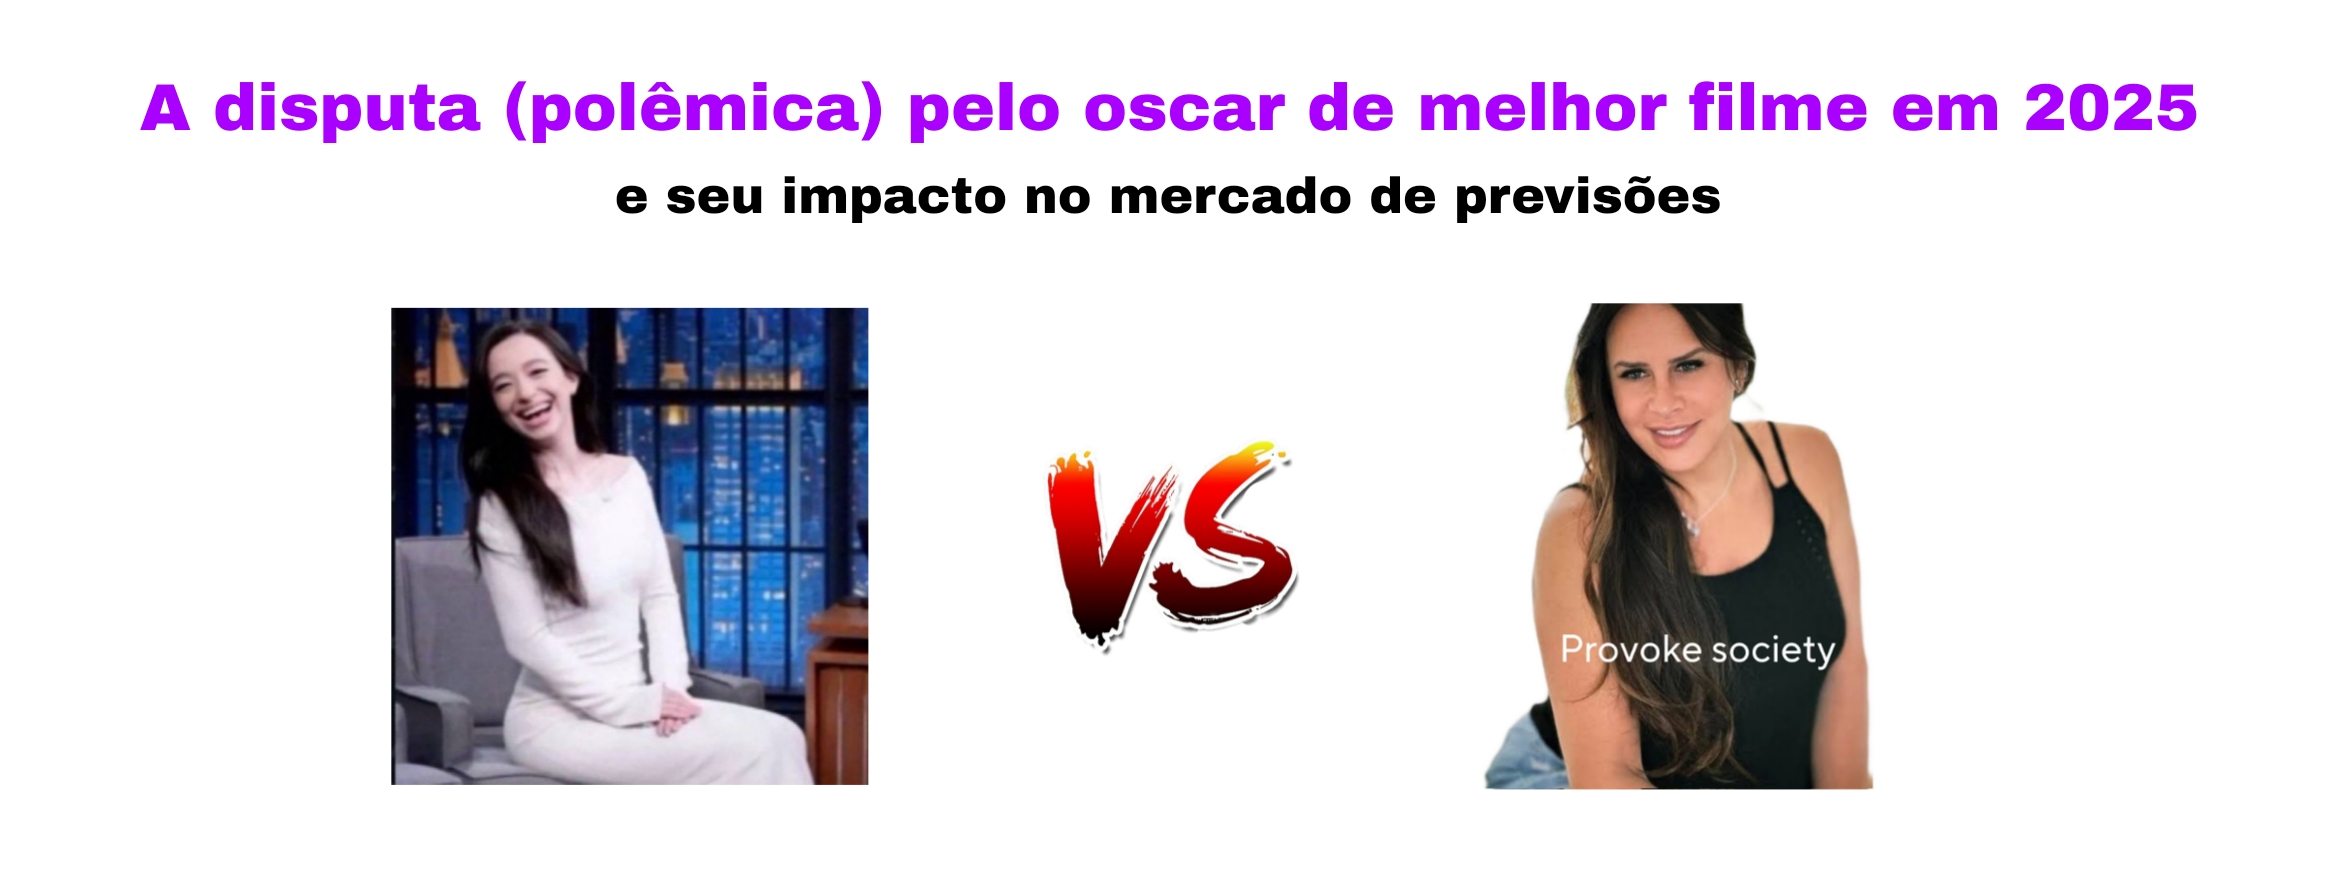

# O Mercado preditivo do Oscar 2025

## 1. Evento Escolhido, Pergunta de Pesquisa e Hipótese Inicial

**Evento escolhido:** Vencedor do oscar de melhor filme em 2025

A 97ª edição do Oscar ocorreu em 2 de março de 2025, com o vencedor do prêmio de melhor filme sendo Anora, dirigido por Sean Baker, que concorreu com fortes produções como O Brutalista, Conclave, Emilia Pérez e Ainda Estou Aqui.

**Pergunta central:** Como o mercado de apostas foi influenciado por vitórias em premiações preliminares e a polêmicas relacionadas aos filmes concorrentes?

**Hipótese inicial:** Consideramos duas circunstâncias externas relevantes que culminaram para o desfecho deste mercado:

* Polêmicas envolvendo a atriz de um dos filmes: Em 31 de janeiro, a atriz espanhola Karla Sofía Gascón, estrela de Emilia Pérez, esteve no centro de polêmicas nas redes sociais. A hipótese é de que esse evento gerou um sell-off (queda abrupta na probabilidade do filme por pânico dos investidores), provocando uma migração em massa de liquidez para seu principal concorrente (Anora).
* Vitórias importantes de um filme em premiações anteriores: Anora ganhou as principais categorias em três grandes premiações preliminares: o Critics Choice Awards (07/Fev) e, mais criticamente, os prêmios do Sindicato dos Produtores (PGA) e Sindicato dos Diretores (DGA) no mesmo fim de semana (09/Fev). Supõe-se que o mercado antecipou e reagiu a essas vitórias com picos extremos de volume e ajustes bruscos de probabilidade a favor de Anora.

**Período Analisado:** 20 de janeiro de 2025 a 05 de março de 2025.

## 2. Exploração Inicial

Para estruturar o estudo, a exploração do banco de dados iniciou-se pela tabela de dimensões (`markets`). O objetivo foi buscar o `market_id` do evento "Qual filme ganhará o prêmio de melhor filme no Oscar 2025" utilizando filtros de texto como *oscar* e *best picture* na coluna de perguntas. Em seguida, a tabela de estatísticas diárias foi explorada para confirmar se o mercado possuía liquidez suficiente para análise.

In [ ]:
-- Busca do ID do mercado na tabela de dimensões
SELECT
  market_id,
  question,
  slug,
  active,
  closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%oscar%'
  AND LOWER(question) LIKE '%best picture%';

### Resultado da Exploração:

O dataset retornou o mercado principal e confirmou os IDs de *Anora* (519436) e *Emilia Pérez*. (Ver arquivo salvo em `dados/exploracao_markets.csv`). A partir desta etapa, a análise foi afunilada para as duas produções com maior *buzz* e volatilidade para isolar o ruído de apostas menores.

Visualização da tabela com os market_ids dos mercados de cada filme com apostas no Polymarket para ganhar o prêmio de melhor filme:

In [ ]:
import pandas as pd
df_markets = pd.read_csv('dados/exploracao_markets.csv')
df_markets.head(10)

,market_id,question,slug,end_date
0,519436,"Will ""Anora"" win Best Picture at the 2025 Oscars?",oscars-best-picture-will-anora-win-best-pictur...,2025-03-02 12:00:00 UTC
1,519450,"Will ""The Substance"" win Best Picture at the 2...",will-the-substance-win-best-picture-at-the-202...,2025-03-02 12:00:00 UTC
2,519443,"Will ""A Real Pain"" win Best Picture at the 202...",oscars-best-picture-will-a-real-pain-win-best-...,2025-03-02 12:00:00 UTC
3,519439,"Will ""Conclave"" win Best Picture at the 2025 O...",oscars-best-picture-will-conclave-win-best-pic...,2025-03-02 12:00:00 UTC
4,519442,"Will ""Nickel Boys"" win Best Picture at the 202...",oscars-best-picture-will-nickel-boys-win-best-...,2025-03-02 12:00:00 UTC
5,519448,"Will ""September"" win Best Picture at the 2025 ...",oscars-best-picture-will-september-win-best-pi...,2025-03-02 12:00:00 UTC
6,519437,"Will ""The Brutalist"" win Best Picture at the 2...",oscars-best-picture-will-the-brutalist-win-bes...,2025-03-02 12:00:00 UTC
7,519446,"Will ""Challengers"" win Best Picture at the 202...",oscars-best-picture-will-challengers-win-best-...,2025-03-02 12:00:00 UTC
8,519441,"Will ""Emilia Pérez"" win Best Picture at the 20...",oscars-best-picture-will-emilia-prez-win-best-...,2025-03-02 12:00:00 UTC
9,519440,"Will ""Dune: Part Two"" win Best Picture at the ...",oscars-best-picture-will-dune-part-two-win-bes...,2025-03-02 12:00:00 UTC


Dada a quantidade de filmes indicados e o ruído gerado por ativos de baixa liquidez, a análise foi afunilada para as duas produções que tiveram maior buzz na temporada de premiações: Anora e Emilia Pérez. Essa escolha permitiu estudar de forma clara a correlação inversa entre os ativos, investigando como o colapso de um favorito influencia direta em seu principal concorrente.

## 3. Analisando as tendências existentes dos dois principais filmes concorrentes

Primeiro, para entender a tendência de longo prazo e analisar se eventos marcantes na corrida do oscar podem ser identificados nas mudanças drásticas dos dados utilizamos a camada *Mart* (`daily_market_stats`).

O uso da tabela agregada (`daily_market_stats`) com filtros rigorosos de data (`>= '2025-01-20'`) e partições por `market_id` reduziu drasticamente o custo computacional da exploração. Em seguida, utilizamos CTEs e *Window Functions* (`LAG()`) na tabela transacional para identificar os dias com maior variância de probabilidade (preço médio do ativo no dia), separando o que era movimento de mercado do que era ruído por baixa liquidez.

In [ ]:
-- Analisando em que dias ocorreram as maiores variâncias de probabilidade/preço de Anora
WITH precos_diarios AS (
  SELECT
    DATE(trade_timestamp) AS trade_date,
    ARRAY_AGG(price ORDER BY trade_timestamp DESC LIMIT 1)[OFFSET(0)] AS preco_atual,
    ROUND(SUM(usd_amount), 2) AS daily_usd_volume
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '519436'
    AND DATE(trade_timestamp) BETWEEN '2025-01-20' AND '2025-03-03'
  GROUP BY 1
),
variacao AS (
  SELECT
    trade_date,
    LAG(preco_atual) OVER(ORDER BY trade_date) AS preco_anterior,
    preco_atual,
    daily_usd_volume
  FROM precos_diarios
)
SELECT
  trade_date,
  preco_anterior,
  preco_atual,
  ROUND((preco_atual - preco_anterior), 2) AS variacao_real,
  daily_usd_volume
FROM variacao
WHERE ABS(preco_atual - preco_anterior) >= 0.15 -- Filtra apenas variações bruscas (>15%)
ORDER BY trade_date ASC;

-- Analisando em que dias ocorreram as maiores variâncias de probabilidade/preço de Emilia Pérez
WITH precos_diarios AS (
  SELECT
    DATE(trade_timestamp) AS trade_date,
    ARRAY_AGG(price ORDER BY trade_timestamp DESC LIMIT 1)[OFFSET(0)] AS preco_atual,
    ROUND(SUM(usd_amount), 2) AS daily_usd_volume
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '519436'
    AND DATE(trade_timestamp) BETWEEN '2025-01-20' AND '2025-03-03'
  GROUP BY 1
),
variacao AS (
  SELECT
    trade_date,
    LAG(preco_atual) OVER(ORDER BY trade_date) AS preco_anterior,
    preco_atual,
    daily_usd_volume
  FROM precos_diarios
)
SELECT
  trade_date,
  preco_anterior,
  preco_atual,
  ROUND((preco_atual - preco_anterior), 2) AS variacao_real,
  daily_usd_volume
FROM variacao
WHERE ABS(preco_atual - preco_anterior) >= 0.15 -- Filtra apenas variações bruscas (>15%)
ORDER BY trade_date ASC;

Visualização das tabelas de análise de variação de preço geradas pelas queries:

In [ ]:
from IPython.display import display
print("Tabela de variação do preço (ordenado por dia)")
df_analise_anora = pd.read_csv('dados/analise_variacao_anora.csv')
print("\nAnora")
display(df_analise_anora.head())
print("\nEmilia Pérez")
df_analise_ep = pd.read_csv('dados/analise_variacao_emiliaperez.csv')
display(df_analise_ep.head())

Tabela de variação do preço (ordenado por dia)

Anora


,trade_date,preco_anterior,preco_atual,variacao_real,daily_usd_volume
0,2025-01-22,0.23,0.54,0.31,2285.13
1,2025-01-23,0.54,0.36,-0.18,1826.31
2,2025-01-25,0.41,0.23,-0.18,68.45
3,2025-01-28,0.38,0.15,-0.23,11.95
4,2025-02-01,0.17,0.54,0.36,781.31



Emilia Pérez


,trade_date,preco_anterior,preco_atual,variacao_real,daily_usd_volume
0,2025-01-23,0.25,0.51,0.26,3363.71
1,2025-01-24,0.51,0.83,0.32,180.66
2,2025-01-25,0.83,0.66,-0.17,433.78
3,2025-01-26,0.66,0.28,-0.39,396.32
4,2025-02-01,0.25,0.54,0.29,1199.57


## 4. Os alertas

Foi desenvolvida uma query única (um pipeline analítico) que implementa simultaneamente duas regras de negócio/alertas. A consulta processa os dados granulares em camadas usando CTEs, aplica a modelagem estatística em Rolling Windows e retorna apenas as anomalias relevantes.

Metodologia (regras dos alertas):
1. Alerta de liquidez (Z-Score): O volume da hora atual é comparado com uma janela móvel de 72 horas. Dispara se o volume for $> 2.5$ desvios padrão acima da média recente (Spike).
2. Alerta de preço (Momentum): Mede a variação absoluta da probabilidade frente às últimas 24 horas. Dispara se a variação for $\ge 15\%$.
3. A query enriquece o alerta identificando a pressão de compra (em porcentagem), calculada a partir da coluna `taker_direction = 'BUY'` no momento do alerta.

Alerta para o filme Anora:

In [ ]:
/*
  Camada: polymarket_optimized.trades (Granularidade transacional)
  Período: 20/Jan/2025 a 03/Mar/2025
*/

WITH base_trades AS (
  -- Isola as transações do mercado escolhido e padroniza as colunas
  SELECT
    'Anora' AS filme,
    trade_timestamp,
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS janela_hora,
    usd_amount,
    price,
    taker_direction
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '519436' -- ID do mercado de Anora
    AND DATE(trade_timestamp) BETWEEN '2025-01-20' AND '2025-03-03'
),

metricas_horarias AS (
  -- Agrega os dados por hora, separando o volume total do volume comprador
  SELECT
    filme,
    janela_hora,

    -- Volume financeiro total daquela hora
    SUM(usd_amount) AS volume_total_hora,

    -- Volume focado apenas em ordens agressoras de compra
    SUM(CASE WHEN taker_direction = 'BUY' THEN usd_amount ELSE 0 END) AS volume_compra_hora,

    -- Pega a probabilidade da última transação fechada dentro daquela hora
    ARRAY_AGG(price ORDER BY trade_timestamp DESC LIMIT 1)[OFFSET(0)] AS preco_fechamento_hora
  FROM base_trades
  GROUP BY 1, 2
),

estatisticas_moveis AS (
  -- Aplica as window functions para criar os baselines estatísticos (rolling windows)
  SELECT
    filme,
    janela_hora,
    volume_total_hora,
    volume_compra_hora,
    preco_fechamento_hora,

    -- Média móvel do volume nas últimas 72 horas em segundos
    AVG(volume_total_hora) OVER(
      PARTITION BY filme
      ORDER BY UNIX_SECONDS(janela_hora)
      RANGE BETWEEN 259200 PRECEDING AND 3600 PRECEDING
    ) AS media_vol_72h,

    -- Desvio padrão do volume nas últimas 72 horas (para o cálculo do z-score)
    STDDEV(volume_total_hora) OVER(
      PARTITION BY filme
      ORDER BY UNIX_SECONDS(janela_hora)
      RANGE BETWEEN 259200 PRECEDING AND 3600 PRECEDING
    ) AS stddev_vol_72h,

    -- Probabilidade exata de 24 horas atrás para verificar saltos bruscos no preço
    LAG(preco_fechamento_hora, 24) OVER(
      PARTITION BY filme
      ORDER BY janela_hora
    ) AS preco_24h_atras

  FROM metricas_horarias
),

calculo_alertas AS (
  -- Calcula os indicadores finais de anomalia
  SELECT
    *,

    -- Cálculo do z-score:
    SAFE_DIVIDE((volume_total_hora - media_vol_72h), stddev_vol_72h) AS z_score_volume,

    -- Variação absoluta da probabilidade
    ABS(preco_fechamento_hora - preco_24h_atras) AS delta_preco_absoluto,

    -- Termômetro do mercado (qual foi a fatia compradora desse volume)
    SAFE_DIVIDE(volume_compra_hora, volume_total_hora) AS pct_forca_compradora

  FROM estatisticas_moveis
)

-- Filtro final que retorna apenas os momentos críticos que acionaram as regras
SELECT
  filme,
  janela_hora,
  ROUND(volume_total_hora, 2) AS volume_usd,
  ROUND(z_score_volume, 2) AS z_score,
  ROUND(preco_fechamento_hora, 2) AS probabilidade_atual,
  ROUND(delta_preco_absoluto, 2) AS variacao_24h,
  ROUND(pct_forca_compradora * 100, 2) AS forca_compradora_pct,

  -- Regras de classificação dos alertas
  CASE
    WHEN z_score_volume > 2.5 AND delta_preco_absoluto >= 0.15 AND pct_forca_compradora >= 0.60
      THEN 'CRÍTICO: Spike de volume com forte pressão de COMPRA e salto de probabilidade'
    WHEN z_score_volume > 2.5 AND delta_preco_absoluto >= 0.15 AND pct_forca_compradora < 0.40
      THEN 'CRÍTICO: Spike de volume com forte pressão de VENDA e queda de probabilidade'
    WHEN z_score_volume > 2.5
      THEN 'ALERTA VOLUME: Anomalia extrema de liquidez (Z > 2.5)'
    WHEN delta_preco_absoluto >= 0.15
      THEN 'ALERTA PREÇO: Ajuste brusco de probabilidade (>15% em 24h)'
  END AS tipo_alerta

FROM calculo_alertas
WHERE
  -- Condição de gatilho para a query retornar a linha
  (z_score_volume > 2.5) OR (delta_preco_absoluto >= 0.15)
ORDER BY janela_hora DESC;

Alerta para o filme Emilia Pérez:



> Substituir esse bloco no query anterior




In [ ]:
WITH base_trades AS (
  -- Isola as transações do mercado escolhido e padroniza as colunas
  SELECT
    'Emilia Pérez' AS filme,
    trade_timestamp,
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS janela_hora,
    usd_amount,
    price,
    taker_direction
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '519441' -- ID do mercado de Anora
    AND DATE(trade_timestamp) BETWEEN '2025-01-20' AND '2025-03-03'
),

Visualizando as tabelas de resultados dos alertas:


In [ ]:
from IPython.display import display
df_analise_anora = pd.read_csv('dados/resultado_alertas_anora.csv')
display(df_analise_anora.head())
print("\n")
df_analise_ep = pd.read_csv('dados/resultado_alertas_emiliaperez.csv')
display(df_analise_ep.head())

,filme,janela_hora,volume_usd,z_score,probabilidade_atual,variacao_24h,forca_compradora_pct,tipo_alerta
0,Anora,2025-03-03 08:00:00.000000 UTC,32.58,-0.36,1.0,0.32,0.0,ALERTA PREÇO: Ajuste brusco de probabilidade (...
1,Anora,2025-03-03 07:00:00.000000 UTC,296.04,-0.33,1.0,0.33,0.0,ALERTA PREÇO: Ajuste brusco de probabilidade (...
2,Anora,2025-03-03 06:00:00.000000 UTC,7846.48,0.62,1.0,0.68,0.0,ALERTA PREÇO: Ajuste brusco de probabilidade (...
3,Anora,2025-03-03 05:00:00.000000 UTC,1000.03,-0.23,1.0,0.68,0.0,ALERTA PREÇO: Ajuste brusco de probabilidade (...
4,Anora,2025-03-03 04:00:00.000000 UTC,14389.06,1.47,1.0,0.34,0.0,ALERTA PREÇO: Ajuste brusco de probabilidade (...


,filme,janela_hora,volume_usd,z_score,probabilidade_atual,variacao_24h,forca_compradora_pct,tipo_alerta
0,Emilia Pérez,2025-03-02 23:00:00.000000 UTC,1563.25,4.25,0.00,0.00,1.88,ALERTA VOLUME: Anomalia extrema de liquidez (Z...
1,Emilia Pérez,2025-03-02 21:00:00.000000 UTC,971.70,2.81,0.00,0.00,22.63,ALERTA VOLUME: Anomalia extrema de liquidez (Z...
2,Emilia Pérez,2025-03-02 07:00:00.000000 UTC,2143.66,31.50,0.01,0.00,0.98,ALERTA VOLUME: Anomalia extrema de liquidez (Z...
3,Emilia Pérez,2025-03-01 16:00:00.000000 UTC,92.39,1.13,0.00,0.99,22.20,ALERTA PREÇO: Ajuste brusco de probabilidade (...
4,Emilia Pérez,2025-02-28 10:00:00.000000 UTC,433.65,57.18,0.01,0.00,0.00,ALERTA VOLUME: Anomalia extrema de liquidez (Z...


## 5. Demonstração

A maioria dos alertas disparados não foram falsos positivos gerados por ausência de liquidez (ruído), pois coincidem com movimentações reais que fazem sentido com os eventos relacionados a trajetória até o oscar, alguns deles foram destacados na hipótese inicial, como as controvérsias da atriz de Emilia Pérez em 31/Jan e vitórias importantes de Anora nas premiações de sindicato PGA e DGA em 09/Fev.

Abaixo, a visualização em Python prova o funcionamento do alerta, demonstrando como os marcadores críticos coincidem com os pontos de inflexão no preço do mercado.

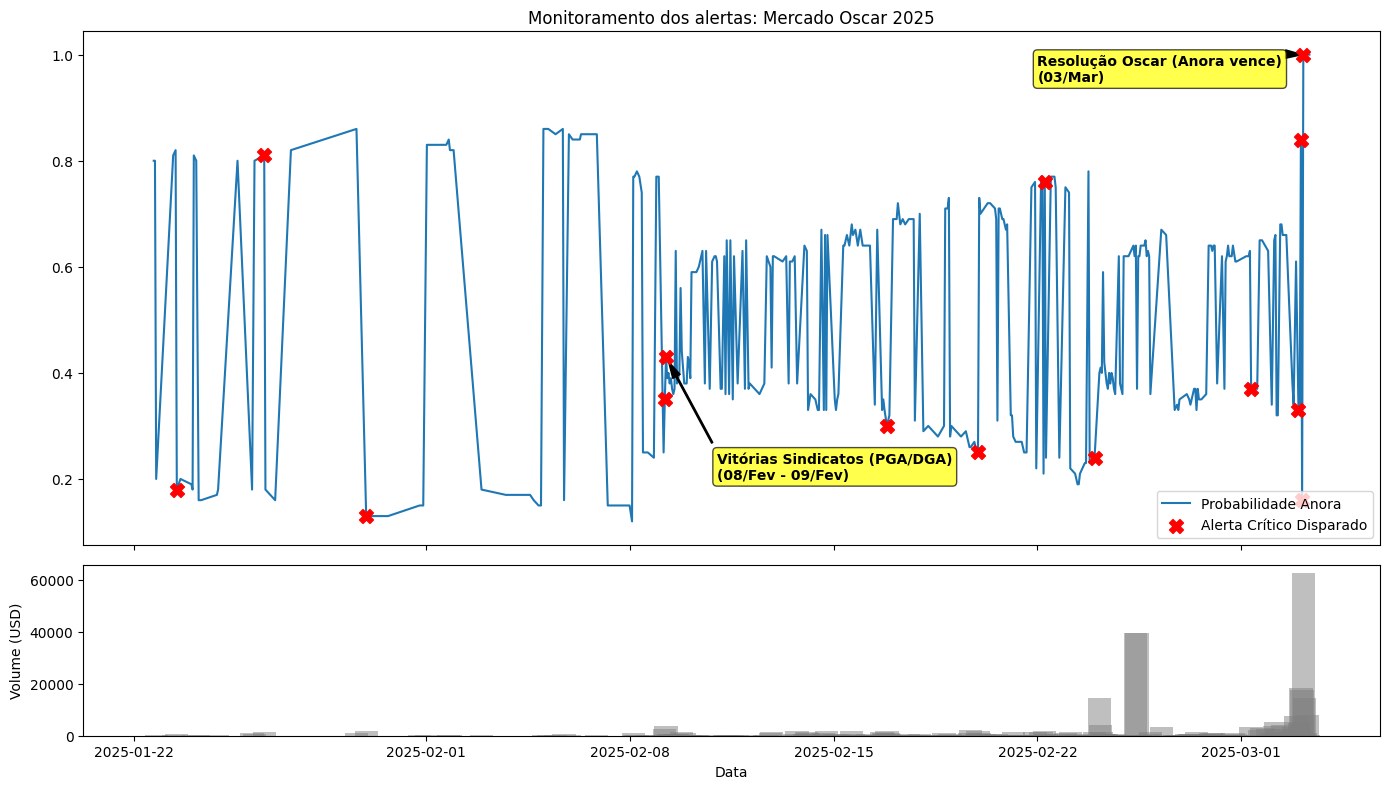

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dados/resultado_alertas_anora.csv')
df['janela_hora'] = pd.to_datetime(df['janela_hora'], utc=True)

alertas_criticos = df[df['tipo_alerta'].str.contains('CRÍTICO')]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Gráfico de salto de probabilidade
ax1.plot(df['janela_hora'], df['probabilidade_atual'], color='#1f77b4', label='Probabilidade Anora')
ax1.scatter(alertas_criticos['janela_hora'], alertas_criticos['probabilidade_atual'],
            color='red', s=100, marker='X', zorder=5, label='Alerta Crítico Disparado')

# Anotações dos eventos das hipóteses
ax1.annotate('Vitórias Sindicatos (PGA/DGA)\n(08/Fev - 09/Fev)',
             xy=(pd.to_datetime('2025-02-09 06:00:00', utc=True), 0.43),
             xytext=(pd.to_datetime('2025-02-11', utc=True), 0.20),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1, alpha=0.7))

ax1.annotate('Resolução Oscar (Anora vence)\n(03/Mar)',
             xy=(pd.to_datetime('2025-03-03 03:00:00', utc=True), 1.00),
             xytext=(pd.to_datetime('2025-02-22', utc=True), 0.95),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1, alpha=0.7))
# ==============================================================================

ax1.set_title('Monitoramento dos alertas: Mercado Oscar 2025')
ax1.legend(loc='lower right')

# Gráfico de spike de volume
ax2.bar(df['janela_hora'], df['volume_usd'], color='gray', alpha=0.5)
ax2.set_ylabel('Volume (USD)')
ax2.set_xlabel('Data')

plt.tight_layout()
plt.show()

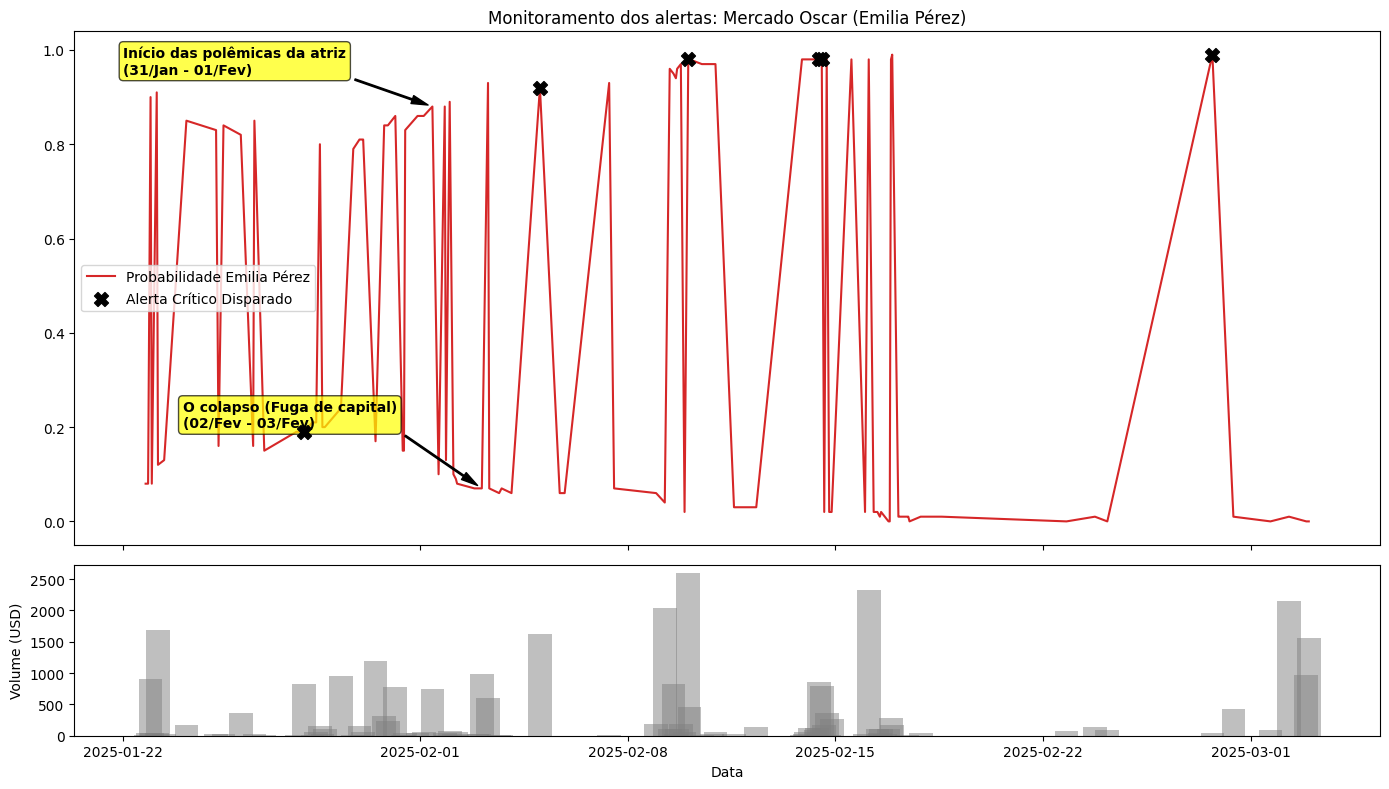

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dados/resultado_alertas_emiliaperez.csv')
df['janela_hora'] = pd.to_datetime(df['janela_hora'], utc=True)

alertas_criticos = df[df['tipo_alerta'].str.contains('CRÍTICO', na=False)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Gráfico de salto/queda de probabilidade
ax1.plot(df['janela_hora'], df['probabilidade_atual'], color='#d62728', label='Probabilidade Emilia Pérez')
ax1.scatter(alertas_criticos['janela_hora'], alertas_criticos['probabilidade_atual'],
            color='black', s=100, marker='X', zorder=5, label='Alerta Crítico Disparado')

# Anotações dos eventos das hipóteses
ax1.annotate('Início das polêmicas da atriz\n(31/Jan - 01/Fev)',
             xy=(pd.to_datetime('2025-02-01 10:00:00', utc=True), 0.88),
             xytext=(pd.to_datetime('2025-01-22', utc=True), 0.95),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1, alpha=0.7))

ax1.annotate('O colapso (Fuga de capital)\n(02/Fev - 03/Fev)',
             xy=(pd.to_datetime('2025-02-03 02:00:00', utc=True), 0.07),
             xytext=(pd.to_datetime('2025-01-24', utc=True), 0.20),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1, alpha=0.7))

ax1.set_title('Monitoramento dos alertas: Mercado Oscar (Emilia Pérez)')
ax1.legend(loc='center left')

# Gráfico de spike de volume
ax2.bar(df['janela_hora'], df['volume_usd'], color='gray', alpha=0.5)
ax2.set_ylabel('Volume (USD)')
ax2.set_xlabel('Data')

plt.tight_layout()
plt.show()